# Statistical Analysis — Nepal Job Market

This notebook performs applied statistics on cleaned job listings data.

**Analyses performed:**
1. Descriptive statistics (mean, median, std, skewness, kurtosis)
2. Correlation & covariance analysis
3. Hypothesis test — One-Way ANOVA (salary by job level)
4. Hypothesis test — Two-Sample T-Test (MeroJob vs KumariJob)
5. Linear regression (salary min → salary max)
6. Chi-Square test of independence (category vs location)
7. Salary summary by job category

> **Prerequisite:** Run `python scheduler.py` at least once so that `jobs.db` contains data.

In [1]:
import sqlite3
import warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

DB_PATH = "jobs.db"

## 1. Load Data

In [2]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM jobs_clean", conn)
conn.close()

df["salary_min"] = pd.to_numeric(df["salary_min"], errors="coerce")
df["salary_max"] = pd.to_numeric(df["salary_max"], errors="coerce")
df["scraped_at"] = pd.to_datetime(df["scraped_at"], errors="coerce")

# Salary subset — realistic values only
sal_df = df[(df["salary_min"].notna()) & (df["salary_min"] > 0) & (df["salary_min"] < 400_000)].copy()

print(f"Total records       : {len(df):,}")
print(f"Records with salary : {len(sal_df):,}")
df.head()

Total records       : 1,163
Records with salary : 937


,source,job_id,title,company,location,category,job_level,skills,salary_min,salary_max,currency,deadline,scraped_at,job_url,experience,education,scrape_date
0,merojob,mj_196756,Electrical Engineer,CTEX Import & Export,"Jhamshikhel-03, Lalitpur","Construction / Engineering / Architects, CAD/ ...",Mid Level,"Work Under Pressure, Fast Learner, Troubleshoo...",15000.0,25000.0,NRs,2026-02-21,2026-02-10 20:19:26,https://www.merojob.com/technical-head-officer/,N/A,N/A,2026-02-10
1,merojob,mj_198103,Cloud Specialist,Simjung,Naxal,IT & Telecommunication,Mid Level,"Technical, Collaboration, Automation, Strategi...",50000.0,60000.0,NRs,2026-02-25,2026-02-10 20:19:26,https://www.merojob.com/cloud-specialist/,N/A,N/A,2026-02-10
2,merojob,mj_197751,Preschool Teacher,Sano Paila Daycare and Early Learning Center,"Imadol, Ochu height","Teaching / Education, Early childhood care and...",Entry Level,"Communication, Monitoring, Montessori Teaching...",20000.0,25000.0,NRs,2026-02-25,2026-02-10 20:19:26,https://www.merojob.com/pre-school-teacher-112/,N/A,N/A,2026-02-10
3,merojob,mj_198092,Education And Visa Counselor,Kharel Law Group,"Lazimpat, Kathmandu",Education Counseling / Career Counseling,Mid Level,"Communication, Counseling, Documentation, Lega...",30000.0,35000.0,NRs,2026-02-25,2026-02-10 20:19:26,https://www.merojob.com/education-and-visa-cou...,N/A,N/A,2026-02-10
4,merojob,mj_198089,Asstistant Handicraft Factory Manager,Felt and Yarn,"Puspalal Path-16, Nayabazzar, Kathmandu, Nepal","General Mgmt. / Administration / Operations, A...",Mid Level,"Communication, Analytical, Administration, Mar...",25000.0,40000.0,NRs,2026-02-25,2026-02-10 20:19:26,https://www.merojob.com/asst-handicraft-factor...,N/A,N/A,2026-02-10


## 2. Descriptive Statistics

Extended summary of `salary_min` including skewness and kurtosis.

In [3]:
sal = sal_df["salary_min"]

stats_dict = {
    "Count"             : len(sal),
    "Mean"              : sal.mean(),
    "Median"            : sal.median(),
    "Std Dev"           : sal.std(),
    "Variance"          : sal.var(),
    "Min"               : sal.min(),
    "25th Percentile"   : sal.quantile(0.25),
    "75th Percentile"   : sal.quantile(0.75),
    "Max"               : sal.max(),
    "IQR"               : sal.quantile(0.75) - sal.quantile(0.25),
    "Skewness"          : sal.skew(),
    "Kurtosis"          : sal.kurtosis(),
    "Coeff of Variation": sal.std() / sal.mean() * 100,
}

summary_df = pd.DataFrame(list(stats_dict.items()), columns=["Statistic", "Value"])

# Skewness interpretation
skew = sal.skew()
if skew > 1:
    interp = "strongly right-skewed (most jobs pay less, few pay a lot)"
elif skew > 0.5:
    interp = "moderately right-skewed"
elif skew < -1:
    interp = "strongly left-skewed"
else:
    interp = "approximately symmetric"

print(f"Interpretation: Salary distribution is {interp}.")
print(f"Kurtosis {sal.kurtosis():.2f} — "
      + ("heavy-tailed (outliers present)" if sal.kurtosis() > 0
         else "light-tailed (few outliers)"))

summary_df

Interpretation: Salary distribution is strongly right-skewed (most jobs pay less, few pay a lot).
Kurtosis 34.28 — heavy-tailed (outliers present)


,Statistic,Value
0,Count,9.370000e+02
1,Mean,3.035944e+04
2,Median,3.000000e+04
3,Std Dev,2.705703e+04
4,Variance,7.320829e+08
5,Min,1.000000e+00
6,25th Percentile,2.000000e+04
7,75th Percentile,3.500000e+04
8,Max,3.550000e+05
9,IQR,1.500000e+04


## 3. Correlation & Covariance Analysis

Pearson correlation between `salary_min` and `salary_max`.

Sample size : 775
Pearson r   : 0.9513
Covariance  : 1,042,238,034.92
Interpretation: Very strong positive correlation.



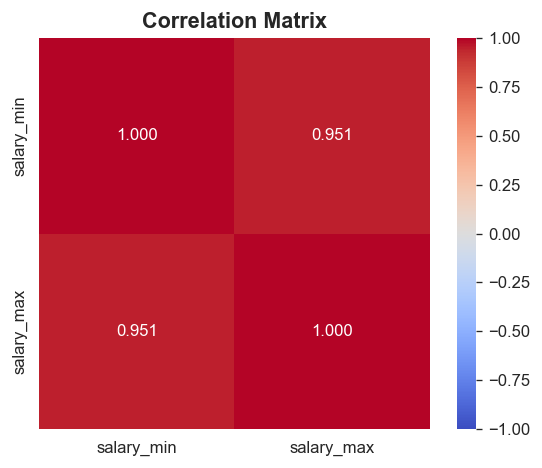

In [4]:
paired = sal_df[
    sal_df["salary_max"].notna() & (sal_df["salary_max"] > 0)
][["salary_min", "salary_max"]].copy()

corr_matrix = paired.corr(method="pearson")
cov_matrix  = paired.cov()
r = corr_matrix.loc["salary_min", "salary_max"]

if abs(r) >= 0.9:   strength = "Very strong"
elif abs(r) >= 0.7:  strength = "Strong"
elif abs(r) >= 0.4:  strength = "Moderate"
else:                strength = "Weak"
direction = "positive" if r > 0 else "negative"

print(f"Sample size : {len(paired)}")
print(f"Pearson r   : {r:.4f}")
print(f"Covariance  : {cov_matrix.loc['salary_min','salary_max']:,.2f}")
print(f"Interpretation: {strength} {direction} correlation.")
print()

# Heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Hypothesis Test — One-Way ANOVA

**Question:** Do different job levels have significantly different salaries?

- **H₀:** All job level groups have the same mean salary
- **H₁:** At least one group mean is different
- **α = 0.05**

Groups tested : ['Entry Level', 'Mid Level', 'Senior Level']
Group sizes   : [189, 593, 148]
F-statistic   : 68.0732
p-value       : 0.000000

RESULT: Reject H0 — significant salary difference across job levels (p < 0.05).

Group means (NPR):
  Entry Level       : NPR     15,081  (n=189)
  Mid Level         : NPR     30,495  (n=593)
  Senior Level      : NPR     45,346  (n=148)


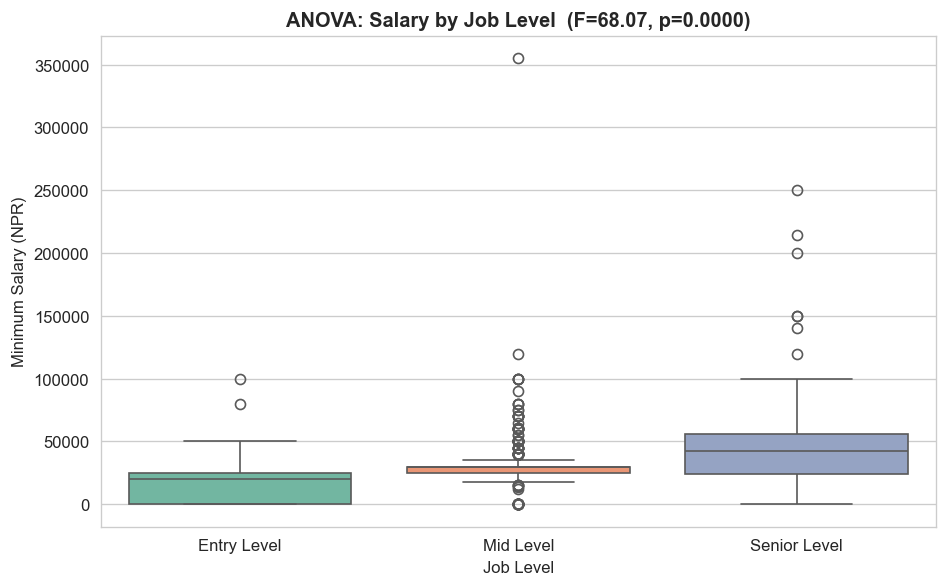

In [5]:
groups = []
labels = []
for level in ["Entry Level", "Mid Level", "Senior Level", "Management"]:
    grp = sal_df[sal_df["job_level"] == level]["salary_min"]
    if len(grp) >= 3:
        groups.append(grp.values)
        labels.append(level)

if len(groups) >= 2:
    f_stat, p_value = stats.f_oneway(*groups)
    reject = p_value < 0.05

    print(f"Groups tested : {labels}")
    print(f"Group sizes   : {[len(g) for g in groups]}")
    print(f"F-statistic   : {f_stat:.4f}")
    print(f"p-value       : {p_value:.6f}")
    print()
    if reject:
        print("RESULT: Reject H0 — significant salary difference across job levels (p < 0.05).")
    else:
        print("RESULT: Fail to reject H0 — no significant difference detected (p >= 0.05).")

    print("\nGroup means (NPR):")
    for label, grp in zip(labels, groups):
        print(f"  {label:<18}: NPR {np.mean(grp):>10,.0f}  (n={len(grp)})")

    # Box plot of salary by level
    plot_df = sal_df[sal_df["job_level"].isin(labels)]
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=plot_df, x="job_level", y="salary_min",
                order=labels, palette="Set2", ax=ax)
    ax.set_title(f"ANOVA: Salary by Job Level  (F={f_stat:.2f}, p={p_value:.4f})",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Job Level")
    ax.set_ylabel("Minimum Salary (NPR)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough groups with sufficient data for ANOVA.")

## 5. Hypothesis Test — Two-Sample T-Test

**Question:** Is there a significant salary difference between MeroJob and KumariJob listings?

- **H₀:** Mean(MeroJob salary) == Mean(KumariJob salary)
- **H₁:** Mean(MeroJob salary) != Mean(KumariJob salary)
- **α = 0.05** (two-tailed, Welch's t-test)

MeroJob   — n=797, mean=NPR 35,376
KumariJob — n=140, mean=NPR 1,802
t-statistic : 30.7678
p-value     : 0.000000

RESULT: Reject H0 — MeroJob offers significantly higher salaries (p < 0.05).


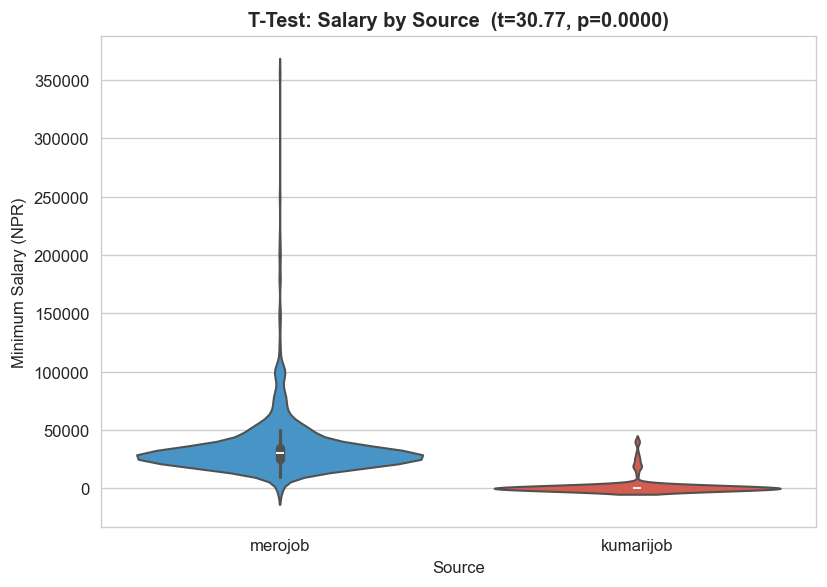

In [6]:
mero   = sal_df[sal_df["source"] == "merojob"]["salary_min"]
kumari = sal_df[sal_df["source"] == "kumarijob"]["salary_min"]

if len(mero) >= 5 and len(kumari) >= 5:
    t_stat, p_value = stats.ttest_ind(mero, kumari, equal_var=False)
    reject = p_value < 0.05

    print(f"MeroJob   — n={len(mero)}, mean=NPR {mero.mean():,.0f}")
    print(f"KumariJob — n={len(kumari)}, mean=NPR {kumari.mean():,.0f}")
    print(f"t-statistic : {t_stat:.4f}")
    print(f"p-value     : {p_value:.6f}")
    print()
    if reject:
        higher = "MeroJob" if mero.mean() > kumari.mean() else "KumariJob"
        print(f"RESULT: Reject H0 — {higher} offers significantly higher salaries (p < 0.05).")
    else:
        print("RESULT: Fail to reject H0 — no significant salary difference (p >= 0.05).")

    # Side-by-side violin plot
    plot_df = sal_df[sal_df["source"].isin(["merojob", "kumarijob"])]
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.violinplot(data=plot_df, x="source", y="salary_min",
                   palette={"merojob": "#3498db", "kumarijob": "#e74c3c"}, ax=ax)
    ax.set_title(f"T-Test: Salary by Source  (t={t_stat:.2f}, p={p_value:.4f})",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Source")
    ax.set_ylabel("Minimum Salary (NPR)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data from one or both sources.")

## 6. Linear Regression — Salary Min predicts Salary Max

**Model:** `salary_max = intercept + slope × salary_min`

Sample size   : 775
Intercept     : NPR -2,686
Slope         : 1.4695
R-squared     : 0.9049  (90.5% variance explained)
Correlation r : 0.9513
p-value       : 0.00e+00  (significant)
Std Error     : 0.0171


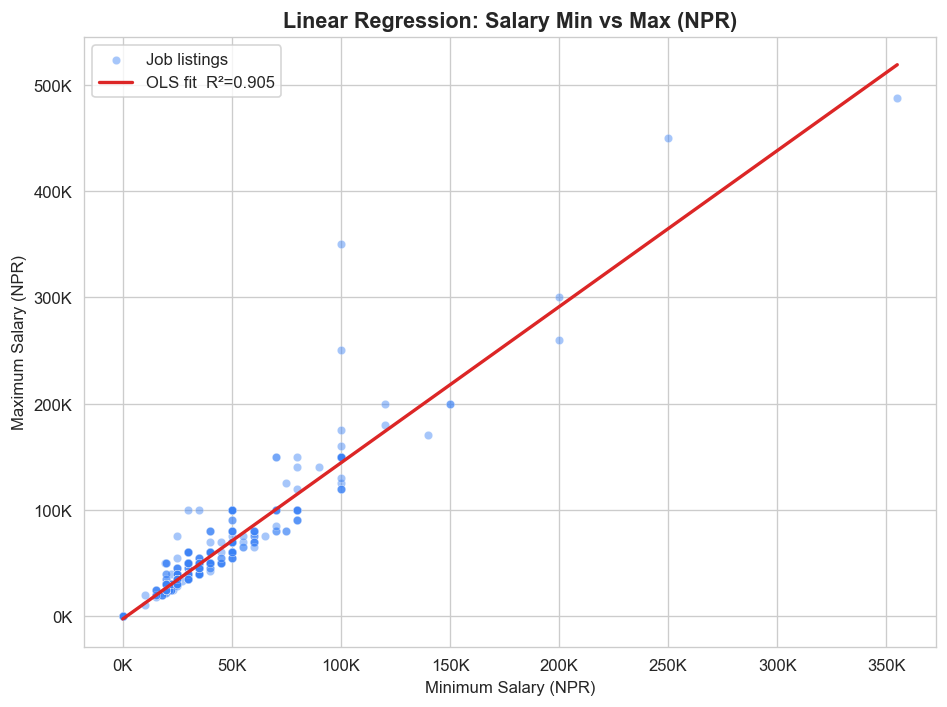

In [7]:
reg_df = sal_df[
    sal_df["salary_max"].notna() &
    (sal_df["salary_max"] > 0) &
    (sal_df["salary_max"] < 500_000)
][["salary_min", "salary_max"]].dropna()

if len(reg_df) >= 10:
    x = reg_df["salary_min"].values
    y = reg_df["salary_max"].values

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r_squared = r_value ** 2

    print(f"Sample size   : {len(reg_df)}")
    print(f"Intercept     : NPR {intercept:+,.0f}")
    print(f"Slope         : {slope:.4f}")
    print(f"R-squared     : {r_squared:.4f}  ({r_squared*100:.1f}% variance explained)")
    print(f"Correlation r : {r_value:.4f}")
    print(f"p-value       : {p_value:.2e}  " + ("(significant)" if p_value < 0.05 else "(not significant)"))
    print(f"Std Error     : {std_err:.4f}")

    # Scatter + fit line
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(x, y, alpha=0.45, s=25, color="#3b82f6",
               edgecolors="white", linewidths=0.3, label="Job listings")
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, intercept + slope * x_line,
            color="#dc2626", linewidth=2.0,
            label=f"OLS fit  R²={r_squared:.3f}")
    ax.set_title("Linear Regression: Salary Min vs Max (NPR)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Minimum Salary (NPR)")
    ax.set_ylabel("Maximum Salary (NPR)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}K"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}K"))
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Not enough paired salary data for regression.")

## 7. Chi-Square Test — Category vs Location

**Question:** Are certain job categories more concentrated in specific cities?

- **H₀:** Job category and location are independent
- **H₁:** Category and location are associated
- **α = 0.05**

Contingency table (top 6 categories x top 5 cities):


location,Dhangadhi,Kathmandu,Naxal,Pokhara,"Samakhusi Chowk, Tokha – 10, Kathmandu, Nepal"
category,,,,,
Accounting / Finance,0,6,2,0,0
General Mgmt. / Administration / Operations,0,1,0,5,0
IT & Telecommunication,0,30,4,0,0
Marketing / Advertising / Customer Service,0,1,1,1,1
Sales / Public Relations,0,2,0,0,0
"Teaching / Education, Primary/ Secondary/ High school teaching",6,0,3,0,17



Chi-square statistic : 127.1717
Degrees of freedom   : 20
p-value              : 0.000000

RESULT: Reject H0 — category and location ARE significantly associated.


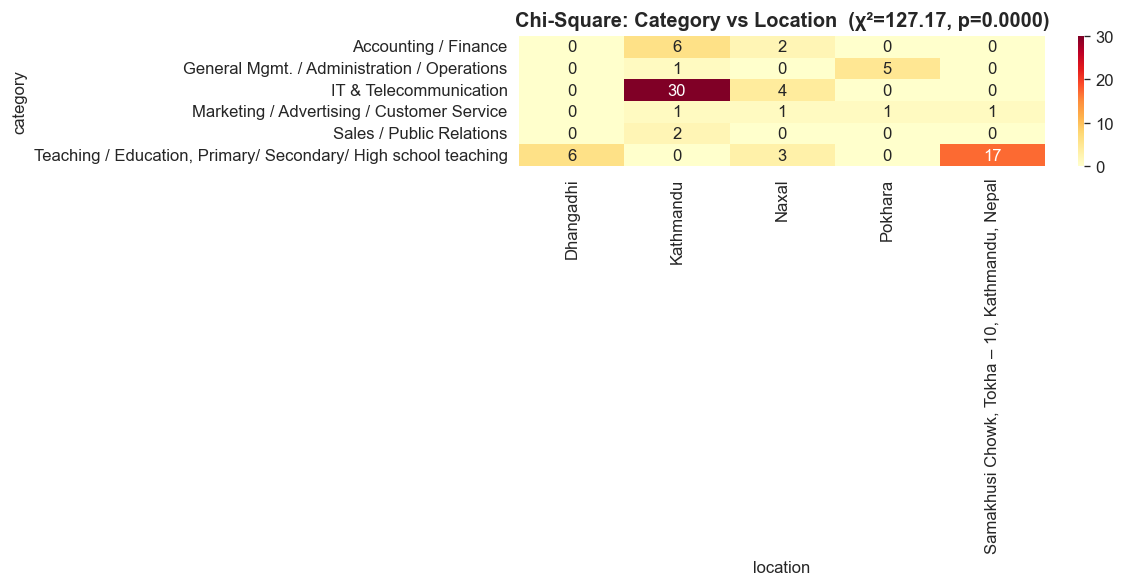

In [8]:
top_cats = df["category"].value_counts().head(6).index
top_locs = (df[df["location"] != "Unknown"]["location"]
            .value_counts().head(5).index)

sub = df[df["category"].isin(top_cats) & df["location"].isin(top_locs)]

if len(sub) >= 20:
    contingency = pd.crosstab(sub["category"], sub["location"])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    reject = p_value < 0.05

    print("Contingency table (top 6 categories x top 5 cities):")
    display(contingency)
    print(f"\nChi-square statistic : {chi2:.4f}")
    print(f"Degrees of freedom   : {dof}")
    print(f"p-value              : {p_value:.6f}")
    print()
    if reject:
        print("RESULT: Reject H0 — category and location ARE significantly associated.")
    else:
        print("RESULT: Fail to reject H0 — no significant association (p >= 0.05).")

    # Heatmap of contingency table
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(contingency, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
    ax.set_title(f"Chi-Square: Category vs Location  (χ²={chi2:.2f}, p={p_value:.4f})",
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for chi-square test.")

## 8. Salary Summary by Job Category

In [9]:
summary = (
    sal_df.groupby("category")["salary_min"]
    .agg(Count="count", Mean="mean", Median="median",
         Std="std", Min="min", Max="max")
    .query("Count >= 3")
    .sort_values("Median", ascending=False)
    .head(15)
)

# Format for display
display(summary.style.format({
    "Mean": "NPR {:,.0f}", "Median": "NPR {:,.0f}",
    "Std": "NPR {:,.0f}", "Min": "NPR {:,.0f}", "Max": "NPR {:,.0f}"
}))

,Count,Mean,Median,Std,Min,Max
category,,,,,,
"IT & Telecommunication, Programmer/ Software Engineer",10,"NPR 79,000","NPR 70,000","NPR 50,925","NPR 30,000","NPR 200,000"
"Teaching / Education, School/ college administration",8,"NPR 55,000","NPR 50,000","NPR 25,635","NPR 20,000","NPR 100,000"
"Construction / Engineering / Architects, Electrical/ Electronics",4,"NPR 41,250","NPR 42,500","NPR 10,308","NPR 30,000","NPR 50,000"
Human Resource /Org. Development,7,"NPR 57,143","NPR 40,000","NPR 55,216","NPR 25,000","NPR 180,000"
Construction / Engineering / Architects,8,"NPR 47,500","NPR 37,500","NPR 25,635","NPR 25,000","NPR 100,000"
Creative / Graphics / Designing,8,"NPR 33,750","NPR 32,500","NPR 9,910","NPR 20,000","NPR 50,000"
"Construction / Engineering / Architects, Mechanical",4,"NPR 33,750","NPR 32,500","NPR 4,787","NPR 30,000","NPR 40,000"
Education Counseling / Career Counseling,24,"NPR 34,625","NPR 30,000","NPR 12,690","NPR 20,000","NPR 60,000"
"General Mgmt. / Administration / Operations, Administration",3,"NPR 28,333","NPR 30,000","NPR 2,887","NPR 25,000","NPR 30,000"


---
## Analysis Complete

All statistical tests, regression, and summaries have been computed and visualized inline.

# Statistical Analysis — Nepal Job Market

Covers Chapter 6 of the syllabus:
- **6.1** Statistical measures: correlation, covariance, skewness, kurtosis
- **6.2** Probability review, sampling, and hypothesis testing
- **6.3** Regression and trend analysis
- **6.4** EDA using descriptive and inferential methods

Also demonstrates **OOP for data science** (Chapter 1.4):
- Class-based design: `JobMarketAnalyzer` encapsulates all analysis
- Encapsulation: data and methods together in one class
- Clean public API: `run_full_analysis()`

> **Prerequisite:** Run `python scheduler.py` at least once so that `jobs.db` contains data.

In [10]:
import sqlite3
import warnings

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import os

warnings.filterwarnings("ignore")

from logger import get_logger

logger = get_logger("job_analyzer.statistics")

DB_PATH    = "jobs.db"
CHARTS_DIR = "charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

## Define the `JobMarketAnalyzer` Class

OOP design pattern — encapsulates the database path, loaded data, and all analysis methods.

In [11]:
class JobMarketAnalyzer:
    """
    Object-oriented statistical analysis engine for Nepal job market data.

    Attributes:
        db_path (str): Path to the SQLite database file.
        df      (pd.DataFrame): Full cleaned jobs dataset.
        sal_df  (pd.DataFrame): Subset with valid salary data only.

    Example:
        analyzer = JobMarketAnalyzer("jobs.db")
        analyzer.run_full_analysis()
    """

    def __init__(self, db_path: str = DB_PATH):
        self.db_path = db_path
        self.df      = self._load_data()
        self.sal_df  = self._filter_salary_data()
        logger.info(
            f"JobMarketAnalyzer initialized — "
            f"{len(self.df)} total jobs, "
            f"{len(self.sal_df)} with salary data"
        )

    # ── Private helpers ────────────────────────────────────────

    def _load_data(self) -> pd.DataFrame:
        """Loads jobs_clean table from SQLite and coerces types."""
        conn = sqlite3.connect(self.db_path)
        try:
            df = pd.read_sql("SELECT * FROM jobs_clean", conn)
        except Exception as exc:
            logger.error(f"Failed to load data: {exc}")
            raise
        finally:
            conn.close()

        df["salary_min"] = pd.to_numeric(df["salary_min"], errors="coerce")
        df["salary_max"] = pd.to_numeric(df["salary_max"], errors="coerce")
        df["scraped_at"] = pd.to_datetime(df["scraped_at"], errors="coerce")
        return df

    def _filter_salary_data(self) -> pd.DataFrame:
        """Returns rows with realistic salary_min values."""
        return self.df[
            (self.df["salary_min"].notna()) &
            (self.df["salary_min"] > 0) &
            (self.df["salary_min"] < 400_000)
        ].copy()

    @staticmethod
    def _separator(title: str):
        """Prints a formatted section header."""
        print(f"\n{'═' * 60}")
        print(f"  {title}")
        print('═' * 60)

    # ── 1. Descriptive Statistics ──────────────────────────────

    def descriptive_statistics(self) -> pd.DataFrame:
        self._separator("1. DESCRIPTIVE STATISTICS (Salary — NPR)")

        sal = self.sal_df["salary_min"]

        stats_dict = {
            "Count"            : len(sal),
            "Mean"             : sal.mean(),
            "Median"           : sal.median(),
            "Std Dev"          : sal.std(),
            "Variance"         : sal.var(),
            "Min"              : sal.min(),
            "25th Percentile"  : sal.quantile(0.25),
            "75th Percentile"  : sal.quantile(0.75),
            "Max"              : sal.max(),
            "IQR"              : sal.quantile(0.75) - sal.quantile(0.25),
            "Skewness"         : sal.skew(),
            "Kurtosis"         : sal.kurtosis(),
            "Coeff of Variation": sal.std() / sal.mean() * 100,
        }

        for label, value in stats_dict.items():
            if isinstance(value, (int, np.integer)):
                print(f"  {label:<26}: {value:>10,}")
            else:
                print(f"  {label:<26}: {value:>13,.2f}")

        skew = sal.skew()
        if skew > 1:
            interp = "strongly right-skewed (most jobs pay less, few pay a lot)"
        elif skew > 0.5:
            interp = "moderately right-skewed"
        elif skew < -1:
            interp = "strongly left-skewed"
        else:
            interp = "approximately symmetric"
        print(f"\n  Interpretation: Salary distribution is {interp}.")
        print(f"  Kurtosis {sal.kurtosis():.2f} — "
              + ("heavy-tailed (outliers present)" if sal.kurtosis() > 0
                 else "light-tailed (few outliers)"))

        summary_df = pd.DataFrame(list(stats_dict.items()),
                                  columns=["Statistic", "Value"])
        return summary_df

    # ── 2. Correlation Analysis ────────────────────────────────

    def correlation_analysis(self) -> pd.DataFrame:
        self._separator("2. CORRELATION AND COVARIANCE ANALYSIS")

        paired = self.sal_df[
            self.sal_df["salary_max"].notna() & (self.sal_df["salary_max"] > 0)
        ][["salary_min", "salary_max"]].copy()

        if len(paired) < 5:
            print("  Not enough paired salary data for correlation analysis.")
            return pd.DataFrame()

        corr_matrix = paired.corr(method="pearson")
        cov_matrix  = paired.cov()
        r           = corr_matrix.loc["salary_min", "salary_max"]

        print(f"  Sample size (jobs with both min & max salary): {len(paired)}")
        print(f"\n  Pearson Correlation (salary_min vs salary_max): r = {r:.4f}")
        print(f"  Covariance:                                          {cov_matrix.loc['salary_min','salary_max']:,.2f}")

        if abs(r) >= 0.9:
            strength = "very strong"
        elif abs(r) >= 0.7:
            strength = "strong"
        elif abs(r) >= 0.4:
            strength = "moderate"
        else:
            strength = "weak"
        direction = "positive" if r > 0 else "negative"
        print(f"\n  Interpretation: {strength.title()} {direction} correlation.")
        print(f"  This means companies that offer a higher minimum also tend")
        print(f"  to offer a proportionally higher maximum salary.")

        print("\n  Full correlation matrix:")
        print(corr_matrix.to_string())
        return corr_matrix

    # ── 3. Hypothesis Testing: One-Way ANOVA ──────────────────

    def anova_salary_by_level(self) -> dict:
        self._separator("3. HYPOTHESIS TEST — One-Way ANOVA")
        print("  Question: Do different job levels have significantly")
        print("  different salary distributions?")
        print()
        print("  H₀ (Null Hypothesis):      All job level means are equal")
        print("  H₁ (Alt.  Hypothesis):     At least one mean is different")
        print("  Significance level (α):    0.05")

        groups = []
        labels = []
        for level in ["Entry Level", "Mid Level", "Senior Level", "Management"]:
            grp = self.sal_df[self.sal_df["job_level"] == level]["salary_min"]
            if len(grp) >= 3:
                groups.append(grp.values)
                labels.append(level)

        if len(groups) < 2:
            print("\n  Not enough groups with sufficient data for ANOVA.")
            return {}

        f_stat, p_value = stats.f_oneway(*groups)
        reject = p_value < 0.05

        print(f"\n  Groups tested: {labels}")
        print(f"  Group sizes  : {[len(g) for g in groups]}")
        print(f"\n  F-statistic  : {f_stat:.4f}")
        print(f"  p-value      : {p_value:.6f}")
        print()
        if reject:
            print("  RESULT: Reject H₀ — there IS a statistically significant")
            print("  difference in salaries across job levels (p < 0.05).")
            print("  Senior/Management roles likely pay significantly more.")
        else:
            print("  RESULT: Fail to reject H₀ — no statistically significant")
            print("  difference detected (p >= 0.05). Salary differences may")
            print("  be due to random variation in this dataset.")

        print("\n  Group means (NPR):")
        for label, grp in zip(labels, groups):
            print(f"    {label:<18}: NPR {np.mean(grp):>10,.0f}  (n={len(grp)})")

        return {"f_stat": f_stat, "p_value": p_value, "reject_h0": reject}

    # ── 4. Two-Sample T-Test: MeroJob vs KumariJob Salaries ───

    def ttest_salary_by_source(self) -> dict:
        self._separator("4. HYPOTHESIS TEST — Two-Sample T-Test")
        print("  Question: Is there a significant difference in salaries")
        print("  between MeroJob and KumariJob listings?")
        print()
        print("  H₀: Mean(MeroJob salary) == Mean(KumariJob salary)")
        print("  H₁: Mean(MeroJob salary) != Mean(KumariJob salary)")
        print("  α  = 0.05 (two-tailed)")

        mero   = self.sal_df[self.sal_df["source"] == "merojob"]["salary_min"]
        kumari = self.sal_df[self.sal_df["source"] == "kumarijob"]["salary_min"]

        if len(mero) < 5 or len(kumari) < 5:
            print("\n  Not enough data from one or both sources.")
            return {}

        t_stat, p_value = stats.ttest_ind(mero, kumari, equal_var=False)
        reject = p_value < 0.05

        print(f"\n  MeroJob   — n={len(mero)}, mean=NPR {mero.mean():,.0f}")
        print(f"  KumariJob — n={len(kumari)}, mean=NPR {kumari.mean():,.0f}")
        print(f"\n  t-statistic : {t_stat:.4f}")
        print(f"  p-value     : {p_value:.6f}")
        print()
        if reject:
            higher = "MeroJob" if mero.mean() > kumari.mean() else "KumariJob"
            print(f"  RESULT: Reject H₀ — {higher} listings offer significantly")
            print("  different (higher) salaries on average (p < 0.05).")
        else:
            print("  RESULT: Fail to reject H₀ — no significant salary difference")
            print("  between the two portals was found (p >= 0.05).")

        return {"t_stat": t_stat, "p_value": p_value, "reject_h0": reject}

    # ── 5. Linear Regression: Salary Min → Salary Max ─────────

    def linear_regression(self) -> dict:
        self._separator("5. LINEAR REGRESSION — Salary Min predicts Salary Max")
        print("  Model: salary_max = intercept + slope × salary_min")

        paired = self.sal_df[
            self.sal_df["salary_max"].notna() &
            (self.sal_df["salary_max"] > 0) &
            (self.sal_df["salary_max"] < 500_000)
        ][["salary_min", "salary_max"]].dropna()

        if len(paired) < 10:
            print("\n  Not enough paired salary data for regression.")
            return {}

        x = paired["salary_min"].values
        y = paired["salary_max"].values

        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        r_squared = r_value ** 2

        print(f"\n  Sample size  : {len(paired)}")
        print(f"  Intercept    : NPR {intercept:+,.0f}")
        print(f"  Slope        : {slope:.4f}  "
              "(for every NPR 1 increase in min salary, max increases by this)")
        print(f"  R² score     : {r_squared:.4f}  "
              f"({r_squared*100:.1f}% of variance in max explained by min)")
        print(f"  Correlation r: {r_value:.4f}")
        print(f"  p-value      : {p_value:.2e}  "
              + ("(significant)" if p_value < 0.05 else "(not significant)"))
        print(f"  Std Error    : {std_err:.4f}")

        # Scatter plot with regression line
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(x, y, alpha=0.45, s=25, color="#3b82f6",
                   edgecolors="white", linewidths=0.3,
                   label="Job listings")
        x_line = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_line, intercept + slope * x_line,
                color="#dc2626", linewidth=2.0,
                label=f"OLS fit  R²={r_squared:.3f}")
        ax.set_title("Linear Regression: Salary Min vs Max (NPR)",
                     fontsize=13, fontweight="bold")
        ax.set_xlabel("Minimum Salary (NPR)")
        ax.set_ylabel("Maximum Salary (NPR)")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f"{v/1000:.0f}K"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f"{v/1000:.0f}K"))
        ax.legend()
        path = f"{CHARTS_DIR}/stat_regression.png"
        fig.savefig(path, dpi=140, bbox_inches="tight")
        plt.show()
        logger.info(f"  Regression chart saved: {path}")

        return {
            "slope": slope, "intercept": intercept,
            "r_squared": r_squared, "p_value": p_value
        }

    # ── 6. Chi-Square Test: Category vs Location ──────────────

    def chi_square_category_location(self) -> dict:
        self._separator("6. CHI-SQUARE TEST — Category vs Location")
        print("  Question: Is job category associated with city location?")
        print("  H₀: Category and location are independent")
        print("  H₁: Category and location are NOT independent")
        print("  α  = 0.05")

        top_cats = self.df["category"].value_counts().head(6).index
        top_locs = (self.df[self.df["location"] != "Unknown"]["location"]
                    .value_counts().head(5).index)

        sub = self.df[
            self.df["category"].isin(top_cats) &
            self.df["location"].isin(top_locs)
        ]

        if len(sub) < 20:
            print("\n  Not enough data for chi-square test.")
            return {}

        contingency = pd.crosstab(sub["category"], sub["location"])
        chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
        reject = p_value < 0.05

        print(f"\n  Contingency table (top 6 categories × top 5 cities):")
        print(contingency.to_string())
        print(f"\n  Chi-square statistic : {chi2:.4f}")
        print(f"  Degrees of freedom   : {dof}")
        print(f"  p-value              : {p_value:.6f}")
        print()
        if reject:
            print("  RESULT: Reject H₀ — Category and location ARE significantly")
            print("  associated. Certain job types cluster in specific cities.")
        else:
            print("  RESULT: Fail to reject H₀ — no significant association")
            print("  between job category and city was found (p >= 0.05).")

        return {"chi2": chi2, "p_value": p_value, "dof": dof, "reject_h0": reject}

    # ── 7. Category-Level Summary Table ───────────────────────

    def category_salary_summary(self) -> pd.DataFrame:
        self._separator("7. SALARY SUMMARY BY JOB CATEGORY")

        summary = (
            self.sal_df.groupby("category")["salary_min"]
            .agg(Count="count",
                 Mean="mean",
                 Median="median",
                 Std="std",
                 Min="min",
                 Max="max")
            .query("Count >= 3")
            .sort_values("Median", ascending=False)
            .head(15)
        )

        print(summary.applymap(
            lambda x: f"NPR {x:,.0f}" if isinstance(x, (float, int)) else x
        ).to_string())

        return summary

    # ── 8. Run Full Analysis ───────────────────────────────────

    def run_full_analysis(self):
        print("=" * 60)
        print("  NEPAL JOB MARKET — STATISTICAL ANALYSIS REPORT")
        print(f"  Total records: {len(self.df):,}")
        print(f"  Records with salary: {len(self.sal_df):,}")
        print("=" * 60)

        self.descriptive_statistics()
        self.correlation_analysis()
        self.anova_salary_by_level()
        self.ttest_salary_by_source()
        self.linear_regression()
        self.chi_square_category_location()
        self.category_salary_summary()

        print("\n" + "=" * 60)
        print("  ANALYSIS COMPLETE")
        print("=" * 60)
        logger.info("Full statistical analysis completed.")

## Initialize the Analyzer

Loads data from `jobs.db` and prepares the salary subset.

In [12]:
analyzer = JobMarketAnalyzer(DB_PATH)
print(f"Total records     : {len(analyzer.df):,}")
print(f"With salary data  : {len(analyzer.sal_df):,}")

2026-03-11 21:45:54 | INFO     | job_analyzer.statistics | JobMarketAnalyzer initialized — 1163 total jobs, 937 with salary data
2026-03-11 21:45:54 | INFO     | job_analyzer.statistics | JobMarketAnalyzer initialized — 1163 total jobs, 937 with salary data


Total records     : 1,163
With salary data  : 937


## 1. Descriptive Statistics

Mean, median, std dev, variance, skewness, kurtosis, IQR, coefficient of variation.

In [13]:
desc_df = analyzer.descriptive_statistics()
desc_df


════════════════════════════════════════════════════════════
  1. DESCRIPTIVE STATISTICS (Salary — NPR)
════════════════════════════════════════════════════════════
  Count                     :        937
  Mean                      :     30,359.44
  Median                    :     30,000.00
  Std Dev                   :     27,057.03
  Variance                  : 732,082,913.35
  Min                       :          1.00
  25th Percentile           :     20,000.00
  75th Percentile           :     35,000.00
  Max                       :    355,000.00
  IQR                       :     15,000.00
  Skewness                  :          4.26
  Kurtosis                  :         34.28
  Coeff of Variation        :         89.12

  Interpretation: Salary distribution is strongly right-skewed (most jobs pay less, few pay a lot).
  Kurtosis 34.28 — heavy-tailed (outliers present)


,Statistic,Value
0,Count,9.370000e+02
1,Mean,3.035944e+04
2,Median,3.000000e+04
3,Std Dev,2.705703e+04
4,Variance,7.320829e+08
5,Min,1.000000e+00
6,25th Percentile,2.000000e+04
7,75th Percentile,3.500000e+04
8,Max,3.550000e+05
9,IQR,1.500000e+04


## 2. Correlation & Covariance Analysis

Pearson correlation between `salary_min` and `salary_max`.

In [14]:
corr = analyzer.correlation_analysis()
corr


════════════════════════════════════════════════════════════
  2. CORRELATION AND COVARIANCE ANALYSIS
════════════════════════════════════════════════════════════
  Sample size (jobs with both min & max salary): 775

  Pearson Correlation (salary_min vs salary_max): r = 0.9513
  Covariance:                                          1,042,238,034.92

  Interpretation: Very Strong positive correlation.
  This means companies that offer a higher minimum also tend
  to offer a proportionally higher maximum salary.

  Full correlation matrix:
            salary_min  salary_max
salary_min    1.000000    0.951278
salary_max    0.951278    1.000000


,salary_min,salary_max
salary_min,1.000000,0.951278
salary_max,0.951278,1.000000


## 3. Hypothesis Test — One-Way ANOVA

**H₀:** All job level groups have the same mean salary.  
**H₁:** At least one group has a significantly different mean.

In [15]:
anova_result = analyzer.anova_salary_by_level()
anova_result


════════════════════════════════════════════════════════════
  3. HYPOTHESIS TEST — One-Way ANOVA
════════════════════════════════════════════════════════════
  Question: Do different job levels have significantly
  different salary distributions?

  H₀ (Null Hypothesis):      All job level means are equal
  H₁ (Alt.  Hypothesis):     At least one mean is different
  Significance level (α):    0.05

  Groups tested: ['Entry Level', 'Mid Level', 'Senior Level']
  Group sizes  : [189, 593, 148]

  F-statistic  : 68.0732
  p-value      : 0.000000

  RESULT: Reject H₀ — there IS a statistically significant
  difference in salaries across job levels (p < 0.05).
  Senior/Management roles likely pay significantly more.

  Group means (NPR):
    Entry Level       : NPR     15,081  (n=189)
    Mid Level         : NPR     30,495  (n=593)
    Senior Level      : NPR     45,346  (n=148)


{'f_stat': np.float64(68.0732117799844),
 'p_value': np.float64(2.6035325576831783e-28),
 'reject_h0': np.True_}

## 4. Hypothesis Test — Two-Sample T-Test

**H₀:** Mean(MeroJob salary) == Mean(KumariJob salary)  
**H₁:** Mean(MeroJob salary) != Mean(KumariJob salary)

In [16]:
ttest_result = analyzer.ttest_salary_by_source()
ttest_result


════════════════════════════════════════════════════════════
  4. HYPOTHESIS TEST — Two-Sample T-Test
════════════════════════════════════════════════════════════
  Question: Is there a significant difference in salaries
  between MeroJob and KumariJob listings?

  H₀: Mean(MeroJob salary) == Mean(KumariJob salary)
  H₁: Mean(MeroJob salary) != Mean(KumariJob salary)
  α  = 0.05 (two-tailed)

  MeroJob   — n=797, mean=NPR 35,376
  KumariJob — n=140, mean=NPR 1,802

  t-statistic : 30.7678
  p-value     : 0.000000

  RESULT: Reject H₀ — MeroJob listings offer significantly
  different (higher) salaries on average (p < 0.05).


{'t_stat': np.float64(30.767756908342797),
 'p_value': np.float64(5.045213645077365e-139),
 'reject_h0': np.True_}

## 5. Linear Regression — Salary Min predicts Salary Max

Model: `salary_max = intercept + slope × salary_min`


════════════════════════════════════════════════════════════
  5. LINEAR REGRESSION — Salary Min predicts Salary Max
════════════════════════════════════════════════════════════
  Model: salary_max = intercept + slope × salary_min

  Sample size  : 775
  Intercept    : NPR -2,686
  Slope        : 1.4695  (for every NPR 1 increase in min salary, max increases by this)
  R² score     : 0.9049  (90.5% of variance in max explained by min)
  Correlation r: 0.9513
  p-value      : 0.00e+00  (significant)
  Std Error    : 0.0171


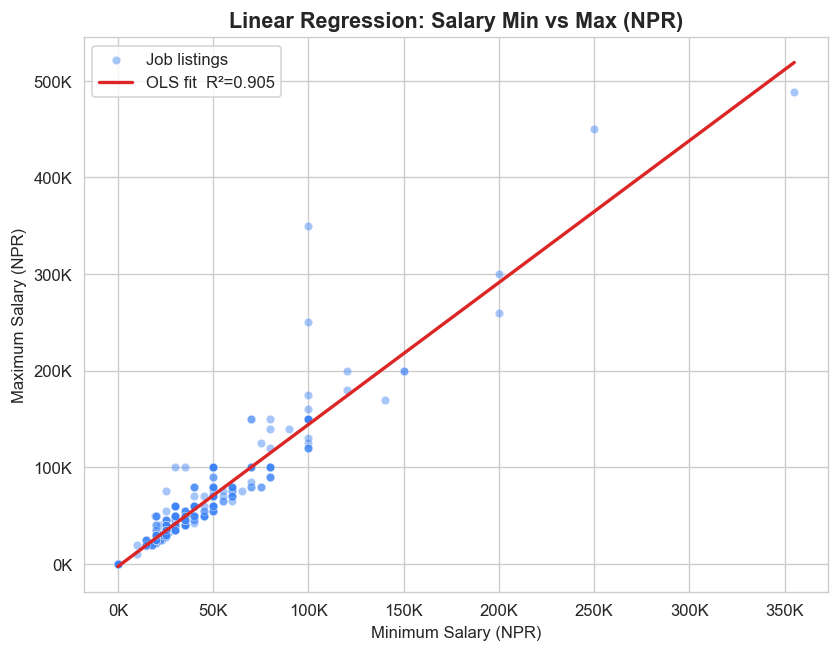

2026-03-11 21:45:55 | INFO     | job_analyzer.statistics |   Regression chart saved: charts/stat_regression.png
2026-03-11 21:45:55 | INFO     | job_analyzer.statistics |   Regression chart saved: charts/stat_regression.png


{'slope': np.float64(1.4695014711888787),
 'intercept': np.float64(-2686.4270796964483),
 'r_squared': np.float64(0.9049305970806942),
 'p_value': np.float64(0.0)}

In [17]:
reg_result = analyzer.linear_regression()
reg_result

## 6. Chi-Square Test — Category vs Location

**H₀:** Job category and location are independent.  
**H₁:** Category and location are associated.

In [18]:
chi2_result = analyzer.chi_square_category_location()
chi2_result


════════════════════════════════════════════════════════════
  6. CHI-SQUARE TEST — Category vs Location
════════════════════════════════════════════════════════════
  Question: Is job category associated with city location?
  H₀: Category and location are independent
  H₁: Category and location are NOT independent
  α  = 0.05

  Contingency table (top 6 categories × top 5 cities):
location                                                        Dhangadhi  Kathmandu  Naxal  Pokhara  Samakhusi Chowk, Tokha – 10, Kathmandu, Nepal
category                                                                                                                                           
Accounting / Finance                                                    0          6      2        0                                              0
General Mgmt. / Administration / Operations                             0          1      0        5                                              0
IT & Telecommunication

{'chi2': np.float64(127.17169431875315),
 'p_value': np.float64(1.319840390346947e-17),
 'dof': 20,
 'reject_h0': np.True_}

## 7. Salary Summary by Job Category

In [19]:
summary_df = analyzer.category_salary_summary()
summary_df


════════════════════════════════════════════════════════════
  7. SALARY SUMMARY BY JOB CATEGORY
════════════════════════════════════════════════════════════
                                                                   Count        Mean      Median         Std         Min          Max
category                                                                                                                             
IT & Telecommunication, Programmer/ Software Engineer             NPR 10  NPR 79,000  NPR 70,000  NPR 50,925  NPR 30,000  NPR 200,000
Teaching / Education, School/ college administration               NPR 8  NPR 55,000  NPR 50,000  NPR 25,635  NPR 20,000  NPR 100,000
Construction / Engineering / Architects, Electrical/ Electronics   NPR 4  NPR 41,250  NPR 42,500  NPR 10,308  NPR 30,000   NPR 50,000
Human Resource /Org. Development                                   NPR 7  NPR 57,143  NPR 40,000  NPR 55,216  NPR 25,000  NPR 180,000
Construction / Engineering / Architec

,Count,Mean,Median,Std,Min,Max
category,,,,,,
"IT & Telecommunication, Programmer/ Software Engineer",10,79000.000000,70000.0,50924.781132,30000.0,200000.0
"Teaching / Education, School/ college administration",8,55000.000000,50000.0,25634.797778,20000.0,100000.0
"Construction / Engineering / Architects, Electrical/ Electronics",4,41250.000000,42500.0,10307.764064,30000.0,50000.0
Human Resource /Org. Development,7,57142.857143,40000.0,55216.025969,25000.0,180000.0
Construction / Engineering / Architects,8,47500.000000,37500.0,25634.797778,25000.0,100000.0
Creative / Graphics / Designing,8,33750.000000,32500.0,9910.312090,20000.0,50000.0
"Construction / Engineering / Architects, Mechanical",4,33750.000000,32500.0,4787.135539,30000.0,40000.0
Education Counseling / Career Counseling,24,34625.000000,30000.0,12689.648297,20000.0,60000.0
"General Mgmt. / Administration / Operations, Administration",3,28333.333333,30000.0,2886.751346,25000.0,30000.0


---
## Analysis Complete

All statistical tests, regression, and summaries have been computed.
The regression chart has been saved to `charts/stat_regression.png`.